# Shot Creation Regression Analysis

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path
import polars as pl
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd().parent/"Additional"
STATSBOMB_DIR = DATA_DIR/"Statsbomb"

# _process = psutil.Process()

df = pl.read_parquet(DATA_DIR / "for_regression.parquet")
df = df.to_pandas()

In [2]:
# shape check
print(df.shape)

# null check
print(df.isnull().sum())

# binary variable creation; was a shot taken during the possession?
df['has_shot'] = (df['n_shots'] > 0).astype(int)
print(df['has_shot'].value_counts(normalize=True))

(641766, 33)
match_id                0
possession_type         0
period                  0
possession              0
OFF_TEAM_ID             0
OFF_MEN_WOMEN           0
OFF_BACKS               0
OFF_MIDFIELDERS         0
OFF_FORWARDS            0
OFF_GOALKEEPER          0
OFF_C0                  0
OFF_C1                  0
OFF_C2                  0
OFF_C3                  0
OFF_C4                  0
OFF_C5                  0
OFF_PLAYERS_ON_PITCH    0
DEF_TEAM_ID             0
DEF_MEN_WOMEN           0
DEF_BACKS               0
DEF_MIDFIELDERS         0
DEF_FORWARDS            0
DEF_GOALKEEPER          0
DEF_C0                  0
DEF_C1                  0
DEF_C2                  0
DEF_C3                  0
DEF_C4                  0
DEF_C5                  0
DEF_PLAYERS_ON_PITCH    0
total_xg                0
n_shots                 0
duration_minutes        0
dtype: int64
has_shot
0    0.879525
1    0.120475
Name: proportion, dtype: float64


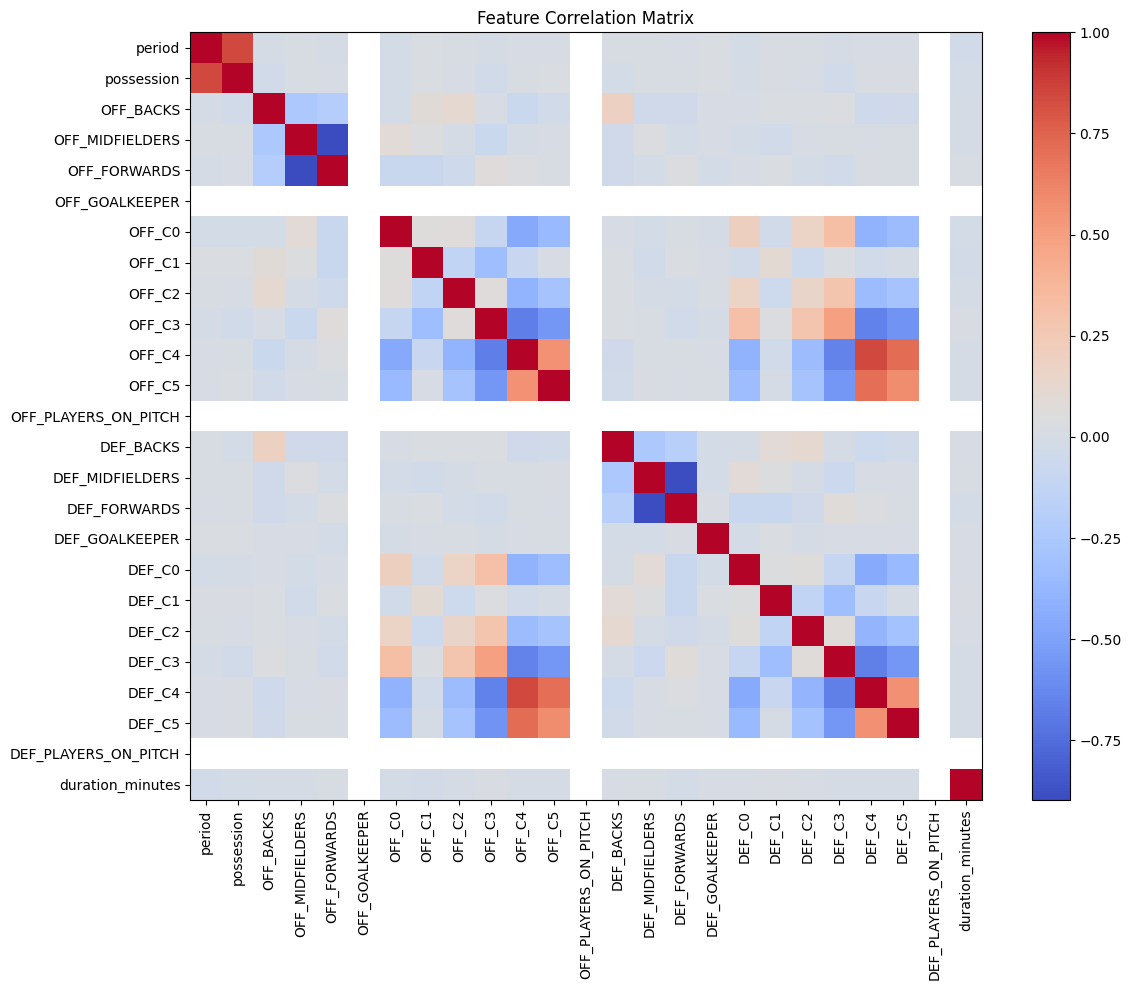

In [3]:
## correlation check

# columns to exclude from numeric features because they are not numbers, or they're response vars
exclude = ['possession_type', 'has_shot', 'total_xg', 'n_shots', 
           'match_id', 'OFF_TEAM_ID', 'DEF_TEAM_ID', 
           'OFF_MEN_WOMEN', 'DEF_MEN_WOMEN']

numeric_features = [col for col in df.columns if col not in exclude]
corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

* OFF_BACKS and OFF_MIDFIELDERS are strongly negatively correlated (same on defensive side), this is  because player position counts sum to a constant (11)
* Cluster columns C0–C5 show internal correlations, especially C3 with C1/C2, attributed to separate men's/women's clusters
* OFF_PLAYERS_ON_PITCH and DEF_PLAYERS_ON_PITCH are constants and  should be excluded from models
* Offensive and defensive features are largely independent of each other
* duration_minutes is uncorrelated with everything

In [5]:
# create IS_MENS and DIFF features first
df['IS_MENS'] = (df['OFF_MEN_WOMEN'] == 'M').astype(int)

for c in ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']:
    df[f'DIFF_{c}'] = df[f'OFF_{c}'] - df[f'DEF_{c}']

#full VIF, some bad values expected
full_feature_cols = (
    ['duration_minutes', 'IS_MENS','OFF_BACKS', 'OFF_MIDFIELDERS', 'OFF_FORWARDS', 'OFF_GOALKEEPER','DEF_BACKS', 'DEF_MIDFIELDERS', 'DEF_FORWARDS', 'DEF_GOALKEEPER',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2', 'DIFF_C3', 'DIFF_C4', 'DIFF_C5'] + [col for col in df.columns if col.startswith('possession_type_')]
)

X_vif_full = df[full_feature_cols].astype(float)
vif_full = pd.DataFrame({
    'feature': full_feature_cols, 'VIF': [variance_inflation_factor(X_vif_full.values, i)
            for i in range(X_vif_full.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_full.to_string())

             feature           VIF
3    OFF_MIDFIELDERS           inf
2          OFF_BACKS           inf
4       OFF_FORWARDS           inf
13           DIFF_C3  2.623735e+04
10           DIFF_C0  1.536919e+04
11           DIFF_C1  8.553947e+03
12           DIFF_C2  7.626529e+03
14           DIFF_C4  7.230523e+03
15           DIFF_C5  2.895416e+03
7    DEF_MIDFIELDERS  2.821248e+03
8       DEF_FORWARDS  2.730225e+03
6          DEF_BACKS  6.027571e+02
9     DEF_GOALKEEPER  3.408381e+00
1            IS_MENS  1.005360e+00
0   duration_minutes  1.000919e+00
5     OFF_GOALKEEPER  0.000000e+00


* OFF_BACKS, OFF_MIDFIELDERS, OFF_FORWARDS are perfectly collinear (inf VIF b/c they sum to a constant w/ OFF_GOALKEEPER).
* All position count columns have extreme VIF, probably should drop all position count columns
* IS_MENS and duration_minutes have VIF around 1.0, meaning they're clean independent features

To sum up, position count columns add nothing beyond what the DIFF cluster features already capture. The variables duration_minutes, IS_MENS, DIFF_C0, DIFF_C1, DIFF_C2, DIFF_C4, DIFF_C5, and possession type dummies should be used going forward. 

### Whittling it Down

In [7]:
df_model = pd.get_dummies(df, columns=['possession_type'], drop_first=True)
df_model['IS_MENS'] = (df_model['OFF_MEN_WOMEN'] == 'M').astype(int)

for c in ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

feature_cols = (
    ['duration_minutes', 'IS_MENS',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2', 'DIFF_C4', 'DIFF_C5']
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

print(f"Number of remaining variables: {len(feature_cols)}")
print(feature_cols)

X_vif = df_model[feature_cols].astype(float)
vif_data = pd.DataFrame({
    'feature': feature_cols, 'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string())

Number of remaining variables: 14
['duration_minutes', 'IS_MENS', 'DIFF_C0', 'DIFF_C1', 'DIFF_C2', 'DIFF_C4', 'DIFF_C5', 'possession_type_Attacking Third - Short', 'possession_type_Defensive Third - Direct', 'possession_type_Defensive Third - Patient', 'possession_type_Defensive Third - Short', 'possession_type_Middle Third - Direct', 'possession_type_Middle Third - Patient', 'possession_type_Middle Third - Short']
                                      feature       VIF
1                                     IS_MENS  5.022535
8    possession_type_Defensive Third - Direct  2.010101
13       possession_type_Middle Third - Short  1.983377
7     possession_type_Attacking Third - Short  1.876669
5                                     DIFF_C4  1.770333
6                                     DIFF_C5  1.645992
10    possession_type_Defensive Third - Short  1.580141
11      possession_type_Middle Third - Direct  1.381085
12     possession_type_Middle Third - Patient  1.185792
2                    

### Train/Test Split and Scaling

In [8]:
X = df_model[feature_cols].astype(float)
y = df_model['has_shot']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Train set shot rate: {y_train.mean():.4f}")
print(f"Test set shot rate: {y_test.mean():.4f}")

Train set size: (513412, 14)
Test set size: (128354, 14)
Train set shot rate: 0.1205
Test set shot rate: 0.1205


### Model Fit and Initial Results

              precision    recall  f1-score   support

           0       0.92      0.54      0.68    112891
           1       0.16      0.65      0.26     15463

    accuracy                           0.56    128354
   macro avg       0.54      0.60      0.47    128354
weighted avg       0.83      0.56      0.63    128354

ROC-AUC: 0.6278


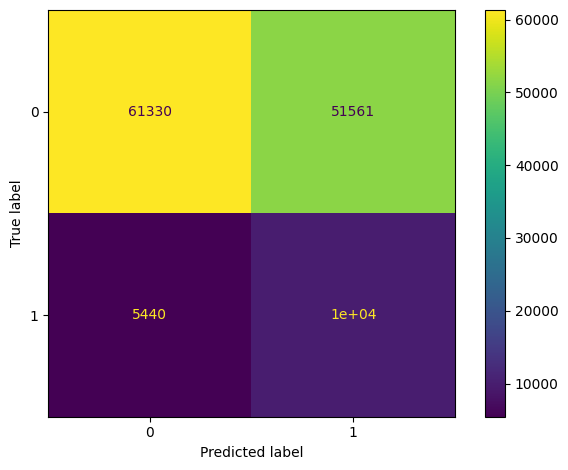

In [9]:
# sklearn fit
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.tight_layout()
plt.show()

Confusion matrix shows 61,330 TNs, 10,000ish TPs, but 51,561 FPs. The balanced weighting is catching shots at the cost of raising a lot of false alarms.
Shot rate by possession type shows some meaningful variation: "Defensive Third - Patient" top @ 23.7%, "Middle Third - Short" lowest @ 6.3%.
Shot possessions have slightly longer mean duration (0.38 min) vs. non-shot possessions (0.31 min)

In [10]:
# check shot rates by possession type to see if there's any signal at all
print(df.groupby('possession_type')['has_shot'].mean().sort_values(ascending=False))

# check if duration has any relationship with shots
print(f"\nMean duration - shot possessions: {df[df['has_shot']==1]['duration_minutes'].mean():.4f}")
print(f"Mean duration - no shot possessions: {df[df['has_shot']==0]['duration_minutes'].mean():.4f}")

possession_type
Defensive Third - Patient    0.236684
Attacking Third - Patient    0.211059
Middle Third - Direct        0.200167
Middle Third - Patient       0.167003
Attacking Third - Short      0.139493
Defensive Third - Short      0.133324
Defensive Third - Direct     0.098191
Middle Third - Short         0.063287
Name: has_shot, dtype: float64

Mean duration - shot possessions: 0.3845
Mean duration - no shot possessions: 0.3096


In [11]:
# find optimal threshold using precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
optimal_threshold = thresholds[f1_scores.argmax()]
print(f"Optimal threshold: {optimal_threshold:.4f}")

# apply optimal threshold
y_pred_adjusted = (y_prob >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_adjusted))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# also try without class_weight but with adjusted threshold
model_default = LogisticRegression(max_iter=1000, random_state=42)
model_default.fit(X_train_scaled, y_train)
y_prob_default = model_default.predict_proba(X_test_scaled)[:, 1]
print(f"\nROC-AUC without class_weight: {roc_auc_score(y_test, y_prob_default):.4f}")

Optimal threshold: 0.5157
              precision    recall  f1-score   support

           0       0.92      0.59      0.71    112891
           1       0.17      0.60      0.26     15463

    accuracy                           0.59    128354
   macro avg       0.54      0.59      0.49    128354
weighted avg       0.82      0.59      0.66    128354

ROC-AUC: 0.6278

ROC-AUC without class_weight: 0.6275


note: genAI used to help explain the following:

**Note on inference model: The statsmodels log. regression below is fit without class weighting, which is common practice for coefficient interpretation. The sklearn model that was used above uses class_weight='balanced' to improve recall on the minority class, but since the ROC-AUC scores are essentially identical with and without class weighting (0.6278 vs 0.6275), the underlying coefficients are not meaningfully affected, so odds ratios should be interpreted as reflecting systematic tendencies in the data rather than the exact decision boundary used for classification.**

### Inference

In [12]:
X_train_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.356687
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               has_shot   No. Observations:               513412
Model:                          Logit   Df Residuals:                   513397
Method:                           MLE   Df Model:                           14
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.03041
Time:                        19:15:10   Log-Likelihood:            -1.8313e+05
converged:                       True   LL-Null:                   -1.8887e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0712      0.005   -447.974      0.000      -2.080      -2.062
x1             0.0036      0.

In [13]:
feature_names = ['const'] + feature_cols
summary_df = pd.DataFrame({
    'variable': feature_names,
    'coefficient': result.params.values,
    'odds_ratio': np.exp(result.params.values),
    'p_value': result.pvalues.values
}).query("variable != 'const'").sort_values('odds_ratio', ascending=False)
print(summary_df.to_string())

                                     variable  coefficient  odds_ratio        p_value
6                                     DIFF_C4     0.068342    1.070731   1.548264e-31
2                                     IS_MENS     0.014101    1.014201   1.692998e-03
10  possession_type_Defensive Third - Patient     0.010749    1.010807   1.875840e-03
12      possession_type_Middle Third - Direct     0.006349    1.006369   2.780787e-01
1                            duration_minutes     0.003632    1.003638   3.226279e-01
7                                     DIFF_C5    -0.017401    0.982749   1.950201e-03
3                                     DIFF_C0    -0.029897    0.970545   3.490388e-11
5                                     DIFF_C2    -0.038656    0.962081   8.461058e-18
13     possession_type_Middle Third - Patient    -0.053769    0.947651   1.926487e-28
4                                     DIFF_C1    -0.124460    0.882973  1.095151e-172
11    possession_type_Defensive Third - Short    -0.17

### Cross-Validation

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"\nCV ROC-AUC scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CV ROC-AUC scores: [0.63078125 0.63082119 0.6321621  0.63008496 0.63259691]
Mean: 0.6313 (+/- 0.0009)


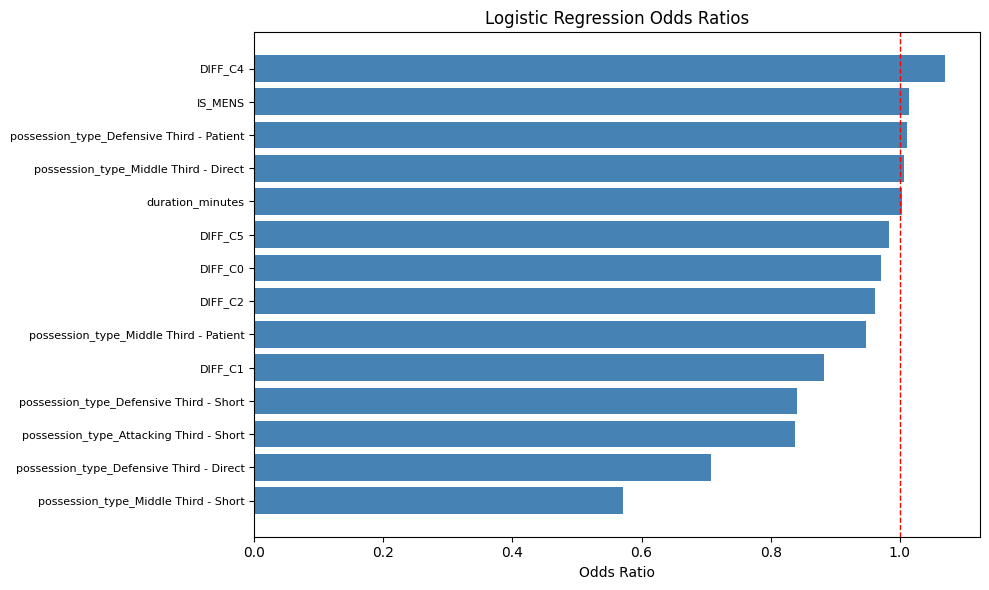

In [18]:
full_plot = summary_df.sort_values('odds_ratio')

plt.figure(figsize=(10, 6))
plt.barh(full_plot['variable'], full_plot['odds_ratio'], color='steelblue')
plt.axvline(x=1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Odds Ratio')
plt.title('Logistic Regression Odds Ratios')
plt.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

* Strongest positive effect: DIFF_C4 (odds ration of about 1.071). Appears that having more women's C4-type players than the opponent slightly increases shot probability
* Strongest negative effects: "possession_type_Middle Third - Short" (OR about 0.571) and "possession_type_Defensive Third - Direct" (OR about 0.707). These possession types strongly reduce shot likelihood relative to the "Attacking Third - Patient" baseline
* DIFF_C1 has a notable negative effect (OR about 0.883). More C1-type players on offense relative to defense reduces shot probability
* IS_MENS is slightly positive and significant (OR about 1.014)
* duration_minutes is positive but not significant